# CN7 · RG3 로지스틱 회귀 학습·테스트
실제 실행 결과를 기본으로 표시합니다. 재학습은 `RUN_NEW_SEARCH=True`로 명시적으로 선택합니다.
고정 분할, 8개 입력 구성 × 15개 C × 2개 가중치, 4-fold OOF, 1001개 임계값입니다.
선택 OOF는 튜닝 점수이고 Test는 이미 관찰한 후속 평가입니다. 운영 승격은 하지 않습니다.
아래 셀은 logistic_regression.py의 코드 사본이며 공통 pipeline_runtime.py와 기존 OCSVM 변환을 재사용합니다.

In [1]:
from pathlib import Path
ROOT=next(p for p in [Path.cwd(),*Path.cwd().parents] if (p/'03.modeling').is_dir())
__file__=str(ROOT/'03.modeling/models/logistic_regression.py')
from IPython.display import display


In [2]:
"""CN7/RG3 LR manual experiment, immutable runs, no deployment.
python 03.modeling/models/logistic_regression.py --dataset cn7
"""
import argparse
import json
from pathlib import Path
import sys
import warnings
import platform
import joblib
import numpy as np
import pandas as pd
import sklearn
from sklearn.exceptions import ConvergenceWarning
from sklearn.metrics import average_precision_score,roc_auc_score

sys.path.insert(0,str(Path(__file__).resolve().parents[1]/'common'))
from pipeline_runtime import (ROOT,Runtime,library,data,write,read,digest,new_id,fit_supervised,
                              score,metrics,range_guidance,write_guidance,topk)

SCENARIOS=['raw_alltrain_scaled','raw','legacy_without_cycle','pressure','plasticizing','thermal','domain_all','group_pca']
C_GRID=np.logspace(-4,3,15)
WEIGHTS=[None,'balanced']
THRESHOLDS=np.linspace(0.,1.,1001)


def run(dataset,run_id=None,state_root=None,scenarios=None):
    scenarios=scenarios or SCENARIOS
    ns=library(dataset);x,y,assignment,dev,test,source=data(dataset)
    out=ROOT/'output/logistic'/dataset/(run_id or new_id('lr'))
    out.mkdir(parents=True,exist_ok=False)
    config=dict(dataset=dataset,scenarios=scenarios,C_values=C_GRID.tolist(),weights=WEIGHTS,
                thresholds=THRESHOLDS.tolist(),source=source,code_sha256=digest(__file__),
                python=platform.python_version(),sklearn=sklearn.__version__,
                runtime_code_sha256=digest(ROOT/'03.modeling/common/pipeline_runtime.py'),
                test_role='previously inspected followup; not independent',label_target='risk history pattern')
    write(out/'run_config.json',config)
    rows=[];all_oof={};audits=[];candidate_id=0;failures=[]
    for scenario in scenarios:
        # Cache fitted transformations per fold, then vary only classifier parameters.
        cache=[]
        for fold in range(4):
            tr=dev[assignment.loc[dev,'cv_fold'].to_numpy()!=fold]
            va=dev[assignment.loc[dev,'cv_fold'].to_numpy()==fold]
            assert not(set(tr)&set(va) or set(tr)&set(test))
            seed=fit_supervised(dataset,x.loc[tr],y.loc[tr],scenario=scenario,C=1.)
            domain=seed['domain'];prep=seed['model'][:-1]
            rawtr=ns['transform_features'](domain,x.loc[tr]) if domain else x.loc[tr]
            rawva=ns['transform_features'](domain,x.loc[va]) if domain else x.loc[va]
            cache.append((fold,tr,va,prep.transform(rawtr),prep.transform(rawva)))
            audits.append(dict(scenario=scenario,fold=fold,train=tr.tolist(),validation=va.tolist(),
                  train_normal=int(y.loc[tr].eq(0).sum()),train_risk=int(y.loc[tr].sum()),
                  scaler_rows=len(tr),domain_reference_rows=int(y.loc[tr].eq(0).sum()) if domain else None))
        for C in C_GRID:
            for weight in WEIGHTS:
                from sklearn.linear_model import LogisticRegression
                folds=[];predictions=[];convergence=[]
                try:
                    for fold,tr,va,tx,vx in cache:
                        model=LogisticRegression(C=float(C),class_weight=weight,solver='lbfgs',max_iter=5000,tol=1e-6,random_state=42)
                        with warnings.catch_warnings():
                            warnings.simplefilter('error',ConvergenceWarning);model.fit(tx,y.loc[tr])
                        s=model.predict_proba(vx)[:,int(np.flatnonzero(model.classes_==1)[0])]
                        folds.append(dict(truth=y.loc[va].to_numpy(),scores=s,
                             AP_reference=float(average_precision_score(y.loc[va],s)),
                             ROC_AUC_reference=float(roc_auc_score(y.loc[va],s))))
                        predictions.append(pd.DataFrame(dict(pattern_row=va,fold=fold,label=y.loc[va].to_numpy(),probability=s)))
                        convergence.append(int(model.n_iter_[0]))
                except ConvergenceWarning as exc:
                    failures.append(dict(candidate_id=candidate_id,scenario=scenario,C=C,weight=weight,error=str(exc)))
                    candidate_id+=1;continue
                table=ns['threshold_trials'](folds,THRESHOLDS).assign(candidate_id=candidate_id,
                     scenario=scenario,C=float(C),class_weight='none' if weight is None else weight,
                     feature_count=max(c[3].shape[1] for c in cache),max_n_iter=max(convergence))
                table.to_csv(out/'threshold_search.csv',mode='w' if not rows else 'a',header=not rows,index=False)
                best=ns['rank_candidates'](table).iloc[0].to_dict();rows.append(best)
                all_oof[candidate_id]=pd.concat(predictions).sort_values('pattern_row')
                candidate_id+=1
        print(dataset,scenario,'completed',flush=True)
    write(out/'failed_candidates.json',failures);write(out/'fold_audit.json',audits)
    if not rows:raise RuntimeError('No converged candidates')
    comparison=pd.DataFrame(rows);ranked=ns['rank_candidates'](comparison)
    ranked.to_csv(out/'candidate_search.csv',index=False)
    choice=ranked.iloc[0].to_dict()
    write(out/'selection_manifest.json',dict(choice=choice,rule='pooled OOF F1, fold F1 std, feature count, candidate ID, threshold',
              test_used=False,config_sha256=digest(out/'run_config.json')))
    frozen=digest(out/'selection_manifest.json')
    oof=all_oof[int(choice['candidate_id'])].copy();oof['threshold']=choice['threshold']
    oof['prediction']=(oof.probability>choice['threshold']).astype(int)
    assert set(oof.pattern_row)==set(dev) and oof.pattern_row.is_unique
    assert np.isclose(metrics(oof.label,oof.prediction)['F1'],choice['F1'])
    oof.to_csv(out/'selected_oof_predictions.csv',index=False)
    bundle=fit_supervised(dataset,x.loc[dev],y.loc[dev],scenario=choice['scenario'],C=choice['C'],
                          class_weight=None if choice['class_weight']=='none' else choice['class_weight'])
    bundle.update(threshold=float(choice['threshold']),choice=choice,selection_sha256=frozen)
    joblib.dump(bundle,out/'model.joblib');scores=score(bundle,x.loc[test])
    np.testing.assert_array_equal(scores,score(joblib.load(out/'model.joblib'),x.loc[test]))
    predictions=scores>bundle['threshold']
    result=dict(**metrics(y.loc[test],predictions),AP=float(average_precision_score(y.loc[test],scores)),
                ROC_AUC=float(roc_auc_score(y.loc[test],scores)),top10=topk(y.loc[test],scores),
                always_normal=metrics(y.loc[test],np.zeros(len(test))),always_risk=metrics(y.loc[test],np.ones(len(test))))
    write(out/'test_metrics.json',result)
    pd.DataFrame(dict(pattern_row=test,label=y.loc[test].to_numpy(),probability=scores,
                     threshold=bundle['threshold'],prediction=predictions.astype(int))).to_csv(out/'test_predictions.csv',index=False)
    model=bundle['model'];domain=bundle['domain']
    names=np.array(domain['feature_names'] if domain else list(x))
    names=names[model[0].get_support()]
    pd.DataFrame(dict(feature=names,coefficient=model[-1].coef_[0],center=model[1].mean_,scale=model[1].scale_)).to_csv(out/'coefficients.csv',index=False)
    write(out/'coefficient_notes.json',dict(intercept=float(model[-1].intercept_[0]),
            meaning='regularized model log-odds; not causal effect or calibrated product defect probability'))
    guidance=range_guidance(x.loc[dev],y.loc[dev],x.loc[test],y.loc[test])
    write_guidance(out,guidance)
    assert digest(out/'selection_manifest.json')==frozen
    evidence={p.name:digest(p) for p in out.iterdir() if p.is_file()}
    write(out/'audit.json',dict(passed=True,artifact_sha256=evidence,oof_exactly_once=True,
               model_reload_identical=True,threshold_frozen=True,train_count=len(dev),
               searched_candidates=candidate_id,completed_candidates=len(rows),failures=len(failures)))
    # Verify all audit-bound artifacts immediately before registration.
    assert all(digest(out/name)==h for name,h in evidence.items())
    version=Runtime(dataset,state_root).save_candidate(bundle,x.loc[dev],y.loc[dev],
                source=dict(run=str(out),evidence_sha256=digest(out/'audit.json'),files=evidence))
    write(out/'registered_candidate.json',dict(version=version,active=False))
    summary=f'''{dataset.upper()} 로지스틱 회귀 결과
입력 구성: {choice['scenario']}, C={choice['C']}, class_weight={choice['class_weight']}, t={choice['threshold']}
개발 OOF F1={choice['F1']:.6f} (튜닝 점수)
Test F1={result['F1']:.6f}, TP={result['TP']}, FP={result['FP']}, FN={result['FN']}, TN={result['TN']}
원변수/도메인 {len(scenarios)}구성, 후보 {candidate_id}개, 성공 {len(rows)}개, 임계값 1001개.
Test는 이미 관찰한 후속 평가이며 독립 성능 아님. 후보 저장만 수행, 운영 승격 없음.
계수는 인과 효과 아님. 구간 안내는 위험 이력 패턴의 관측 통계이며 표본 부족을 표시함.
'''
    (out/'summary.txt').write_text(summary,encoding='utf-8');print(summary,flush=True)
    return out




In [3]:
RUN_NEW_SEARCH=False
DATASET="rg3"
SAVED_RUNS={'cn7': 'output/logistic/cn7/lr-20261003T040927Z-66e8d685', 'rg3': 'output/logistic/rg3/lr-20261003T040950Z-8c8b16ec'}
if RUN_NEW_SEARCH:
    SAVED_RUNS[DATASET]=str(run(DATASET).relative_to(ROOT))


In [4]:
rows=[]
for ds,relative in SAVED_RUNS.items():
    folder=ROOT/relative
    selection=read(folder/'selection_manifest.json')['choice']
    test=read(folder/'test_metrics.json')
    rows.append(dict(dataset=ds,scenario=selection['scenario'],C=selection['C'],class_weight=selection['class_weight'],threshold=selection['threshold'],OOF_F1=selection['F1'],test_F1=test['F1'],TP=test['TP'],FP=test['FP'],FN=test['FN']))
display(pd.DataFrame(rows))

,dataset,scenario,C,class_weight,threshold,OOF_F1,test_F1,TP,FP,FN
0,cn7,thermal,10.000000,none,0.921,0.625000,0.000000,0,0,3
1,rg3,thermal,0.316228,none,0.012,0.089286,0.083333,5,110,0


## 계수와 RG3 분포 구간 안내
계수는 인과 효과가 아닙니다. 구간별 수치는 고유 패턴의 위험 이력이며 제품 불량 확률이 아닙니다. 표본 부족은 반드시 구분합니다.

In [5]:
folder=ROOT/SAVED_RUNS[DATASET]
display(pd.read_csv(folder/'coefficients.csv').assign(abs_coefficient=lambda d:d.coefficient.abs()).sort_values('abs_coefficient',ascending=False).head(12))
g=read(folder/'distribution_guidance.json')
display(pd.DataFrame(g['ranges'])[['variable','interval','reference_patterns','reference_risks','reference_wilson95','evaluation_patterns','evaluation_risks','status','evaluation_support']].sort_values('reference_risks',ascending=False).head(20))
print((folder/'summary.txt').read_text(encoding='utf-8'))

,feature,coefficient,center,scale,abs_coefficient
18,Barrel_Temperature_5,0.389203,0.017493,0.994650,0.389203
13,Average_Back_Pressure,0.376769,0.000463,1.000159,0.376769
10,Max_Injection_Pressure,-0.255261,-0.010586,1.000387,0.255261
9,Average_Screw_RPM,0.203027,0.006130,1.000987,0.203027
7,Max_Injection_Speed,0.194072,0.009608,0.997905,0.194072
6,Plasticizing_Position,-0.189939,-0.010530,0.996007,0.189939
16,Barrel_Temperature_3,-0.185374,-0.002614,0.990256,0.185374
15,Barrel_Temperature_2,-0.181826,-0.007900,0.996917,0.181826
24,배럴_상대편차표준편차,-0.167719,-0.003583,1.002022,0.167719
14,Barrel_Temperature_1,0.146057,0.003172,1.002649,0.146057


,variable,interval,reference_patterns,reference_risks,reference_wilson95,evaluation_patterns,evaluation_risks,status,evaluation_support
43,Clamp_Open_Position,0.0,472,20,"[0.027594899901470956, 0.06453969242545446]",119,5,descriptive_only,sufficient_descriptive_support
0,Injection_Time,-0.029099449053866445,467,20,"[0.02789214942510754, 0.0652208464663393]",116,5,descriptive_only,sufficient_descriptive_support
20,Cycle_Time,0.24951068491762612,300,15,"[0.03053164062934728, 0.08084703347274415]",71,2,descriptive_only,insufficient_support
55,Average_Screw_RPM,-0.4217977735906751,282,12,"[0.024507148927052715, 0.07289460285367419]",63,3,descriptive_only,insufficient_support
48,Max_Injection_Speed,0.6176451529252976,133,11,"[0.04680842545348757, 0.14203389648166997]",27,0,descriptive_only,insufficient_support
188,Injection_Time × Filling_Time,-0.029099449053866445 / 0.8385523411322893,269,10,"[0.020315739634074067, 0.06706635736740196]",73,5,descriptive_only,sufficient_descriptive_support
3,Filling_Time,-1.1925314031676417,199,10,"[0.027521394363559718, 0.09001601125019734]",45,0,descriptive_only,insufficient_support
4,Filling_Time,0.8385523411322893,273,10,"[0.020016278980840557, 0.06610326005877948]",74,5,descriptive_only,sufficient_descriptive_support
27,Clamp_Close_Time,1.0330781477474453,200,10,"[0.02738264560076393, 0.08957814813877599]",49,2,descriptive_only,insufficient_support
187,Injection_Time × Filling_Time,-0.029099449053866445 / -1.1925314031676417,198,10,"[0.027661556517076857, 0.09045817448364726]",43,0,descriptive_only,insufficient_support


RG3 로지스틱 회귀 결과
입력 구성: thermal, C=0.31622776601683794, class_weight=none, t=0.012
개발 OOF F1=0.089286 (튜닝 점수)
Test F1=0.083333, TP=5, FP=110, FN=0, TN=4
원변수/도메인 8구성, 후보 240개, 성공 240개, 임계값 1001개.
Test는 이미 관찰한 후속 평가이며 독립 성능 아님. 후보 저장만 수행, 운영 승격 없음.
계수는 인과 효과 아님. 구간 안내는 위험 이력 패턴의 관측 통계이며 표본 부족을 표시함.



## 결과보고서 v4 시각화

아래 셀만 실행하면 이 노트북에 해당하는 보고서 그림을 표시한다. 기존 학습·전처리·운영 셀을 다시 실행할 필요가 없다.
공통 생성 코드는 `reporting/visualizations.py`에 있다. 그림이 없으면 해당 코드를 먼저 실행한다.
고정 Test는 이미 관찰한 후속 평가이며, RF 연구 v1과 표준화 수정 후 v2를 구분한다.
시각화용 중앙값·IQR 변환은 표시 목적에 한정되며 모델 입력이나 기존 표준화 로직을 변경하지 않는다.


### LR 저장 모델의 Test 점수와 고정 임계값

고유 패턴 CN7 N122·위험3 / RG3 N119·위험5 / lr-20261003T040950Z-62637750 ; lr-20261003T041011Z-d707796f

점수 분포와 고정 임계값을 함께 확인하였다. 위험 탐지와 정상 오탐을 별도로 평가하였다.

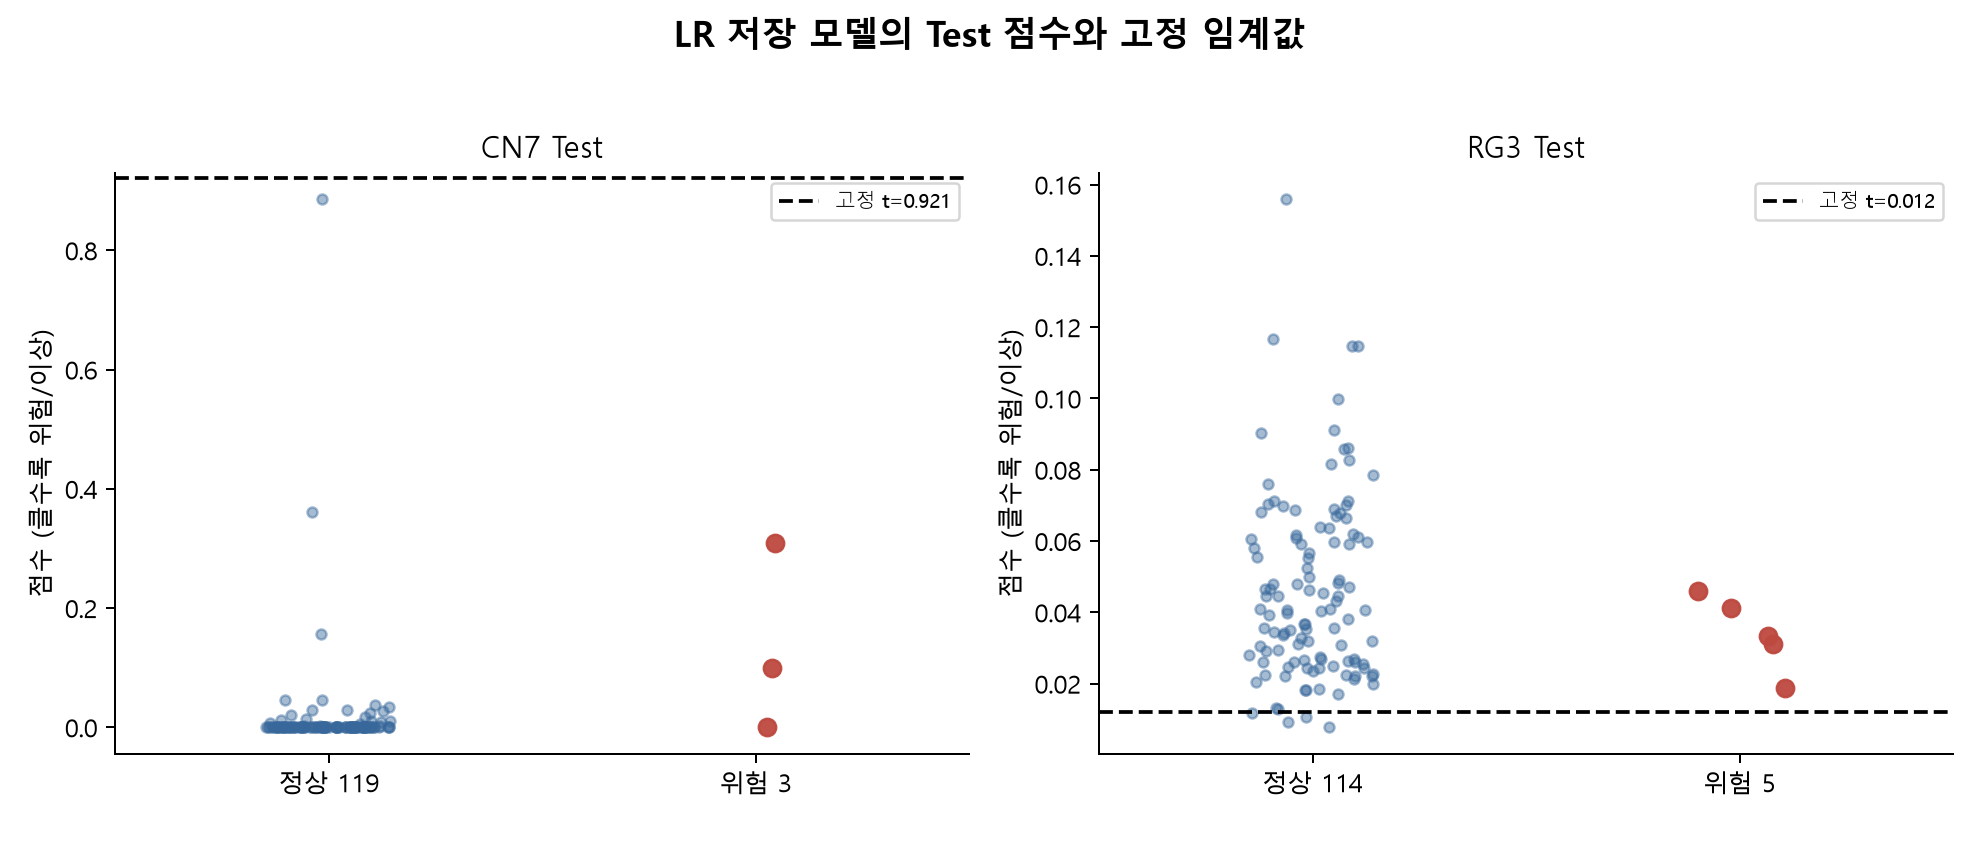

### LR 고정 Test의 FN·FP

같은 고정 패턴 Test / 각 저장 모델의 기존 임계값 / Test로 재선택하지 않음

CN7은 위험 3개를 모두 놓쳤다. RG3는 위험 5개를 탐지하였으나 정상 오탐이 많아 임계값 분류의 실용성이 제한되었다.

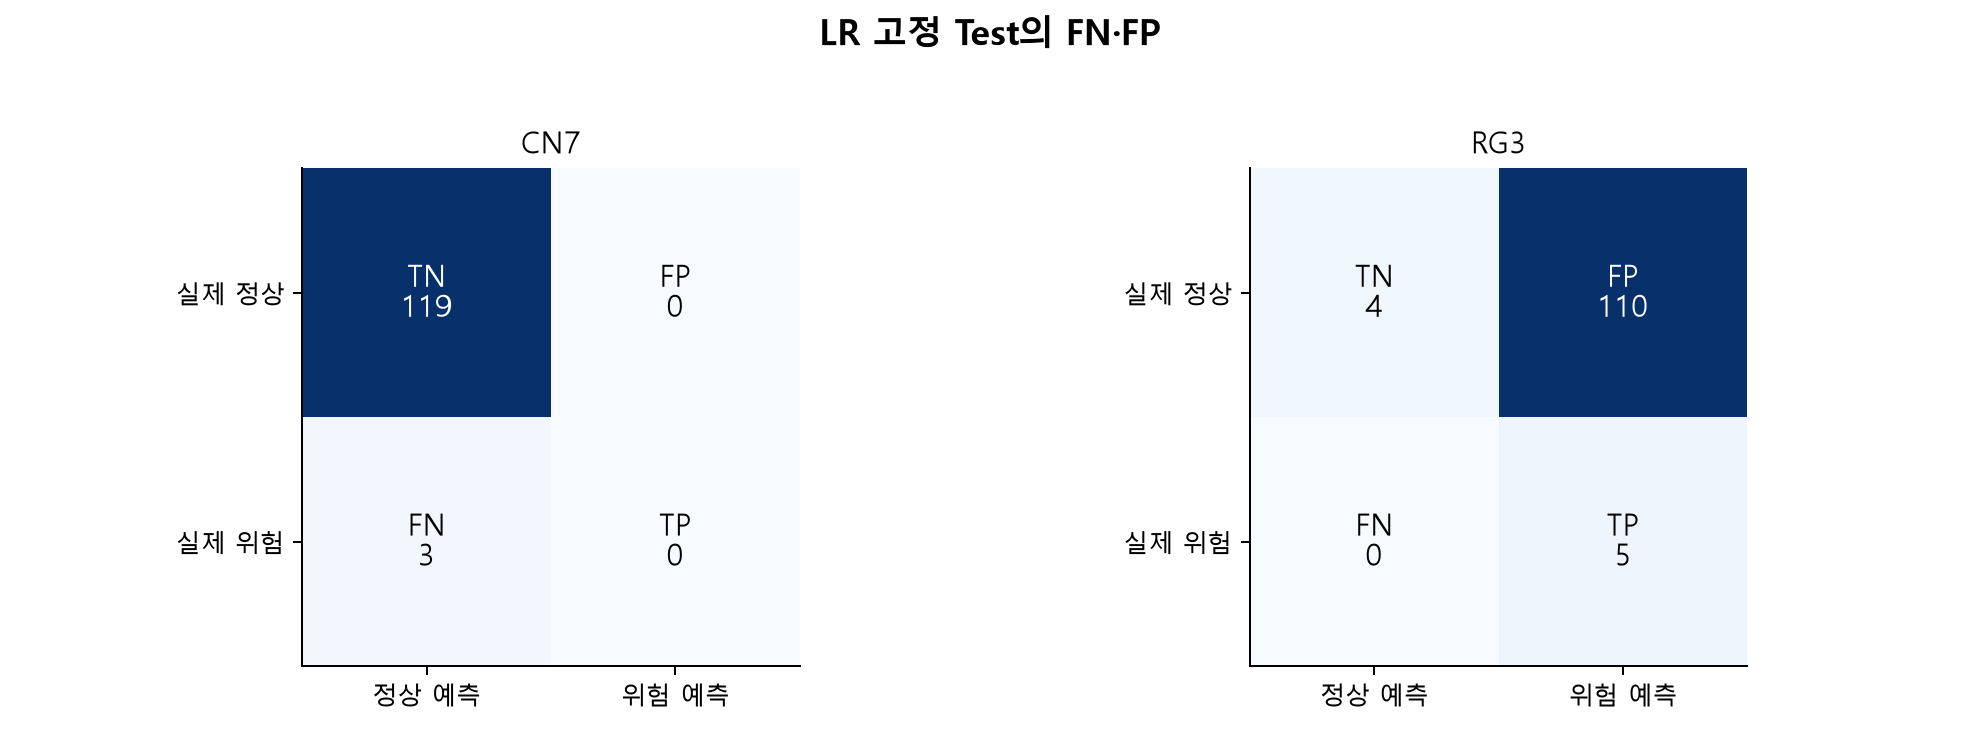

### CN7 LR 개발 OOF와 Test의 구분

output/logistic/cn7/lr-20261003T040927Z-66e8d685 / 개발484·Test122 / 기존 선택 임계값

개발 OOF는 입력 구성·규제 강도·가중치·임계값을 선택한 자료이다. OOF 성능을 독립 일반화 성능으로 표현하지 않았다.

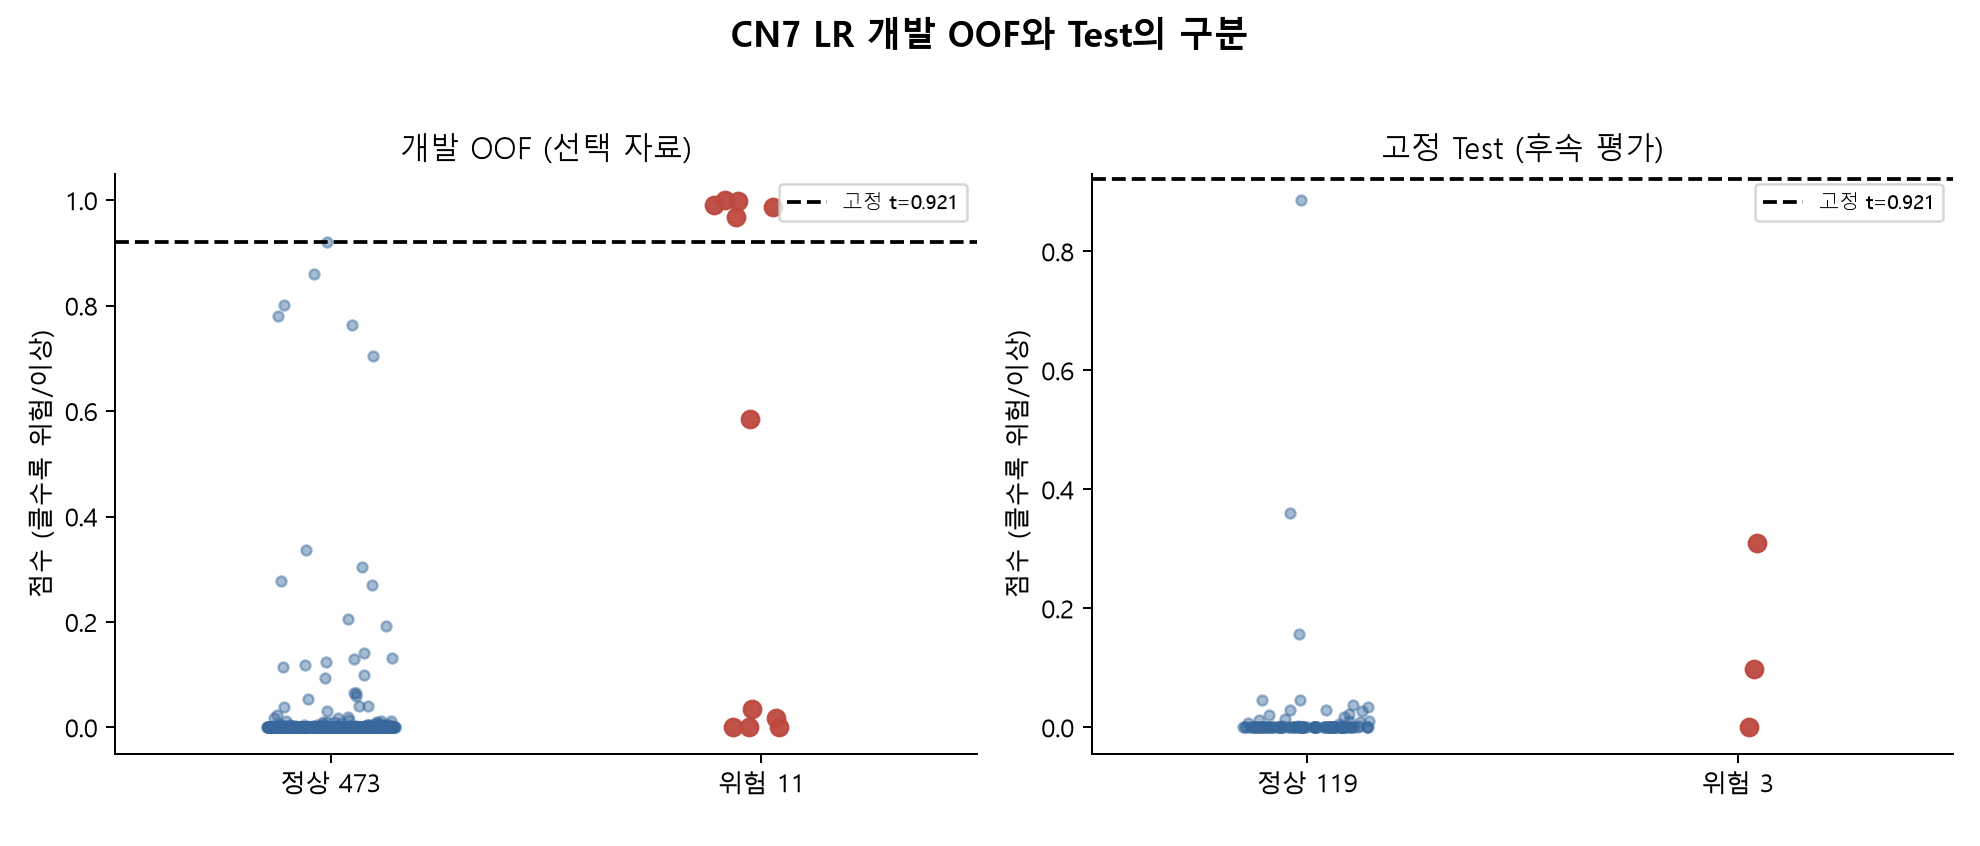

### CN7 선택 LR의 주요 계수

lr-20261003T040950Z-62637750 / 개발 적합 / 상위10 절대계수 / thermal 특징

계수 부호는 다른 입력을 포함한 모델 좌표에서의 관계이다. 물리적 원인이나 최적 공정값으로 해석하지 않았다.

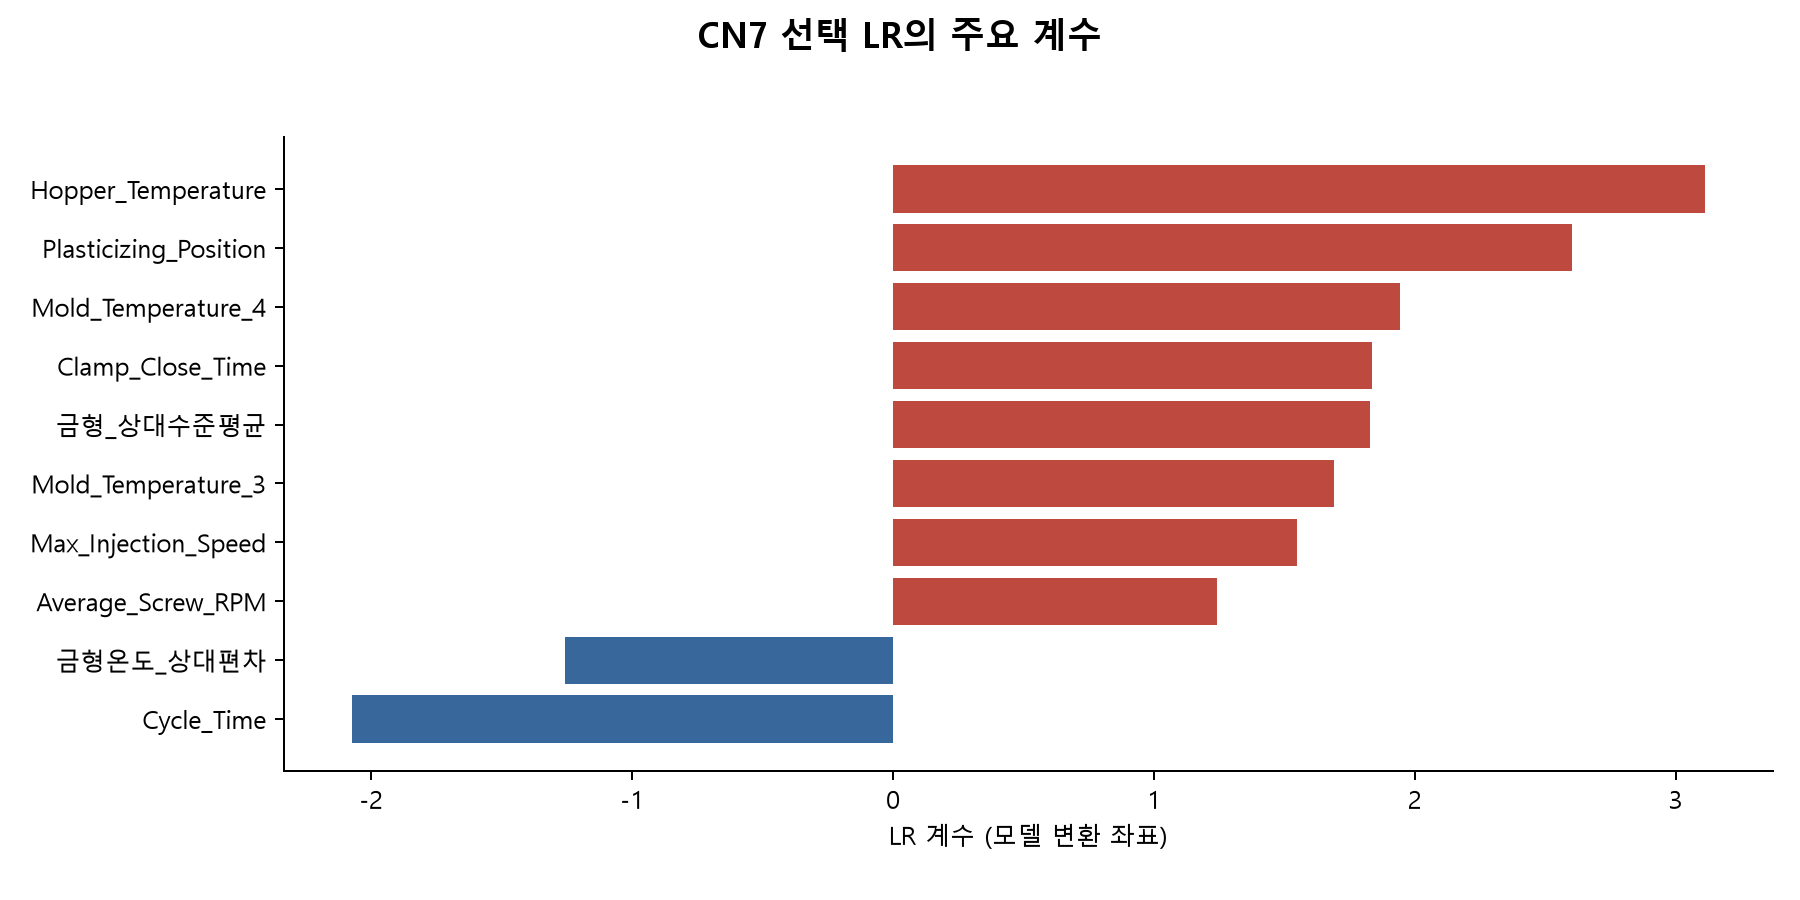

### RG3 LR 개발 OOF와 Test의 구분

output/logistic/rg3/lr-20261003T040950Z-8c8b16ec / 개발472·Test119 / 기존 선택 임계값

개발 OOF는 입력 구성·규제 강도·가중치·임계값을 선택한 자료이다. OOF 성능을 독립 일반화 성능으로 표현하지 않았다.

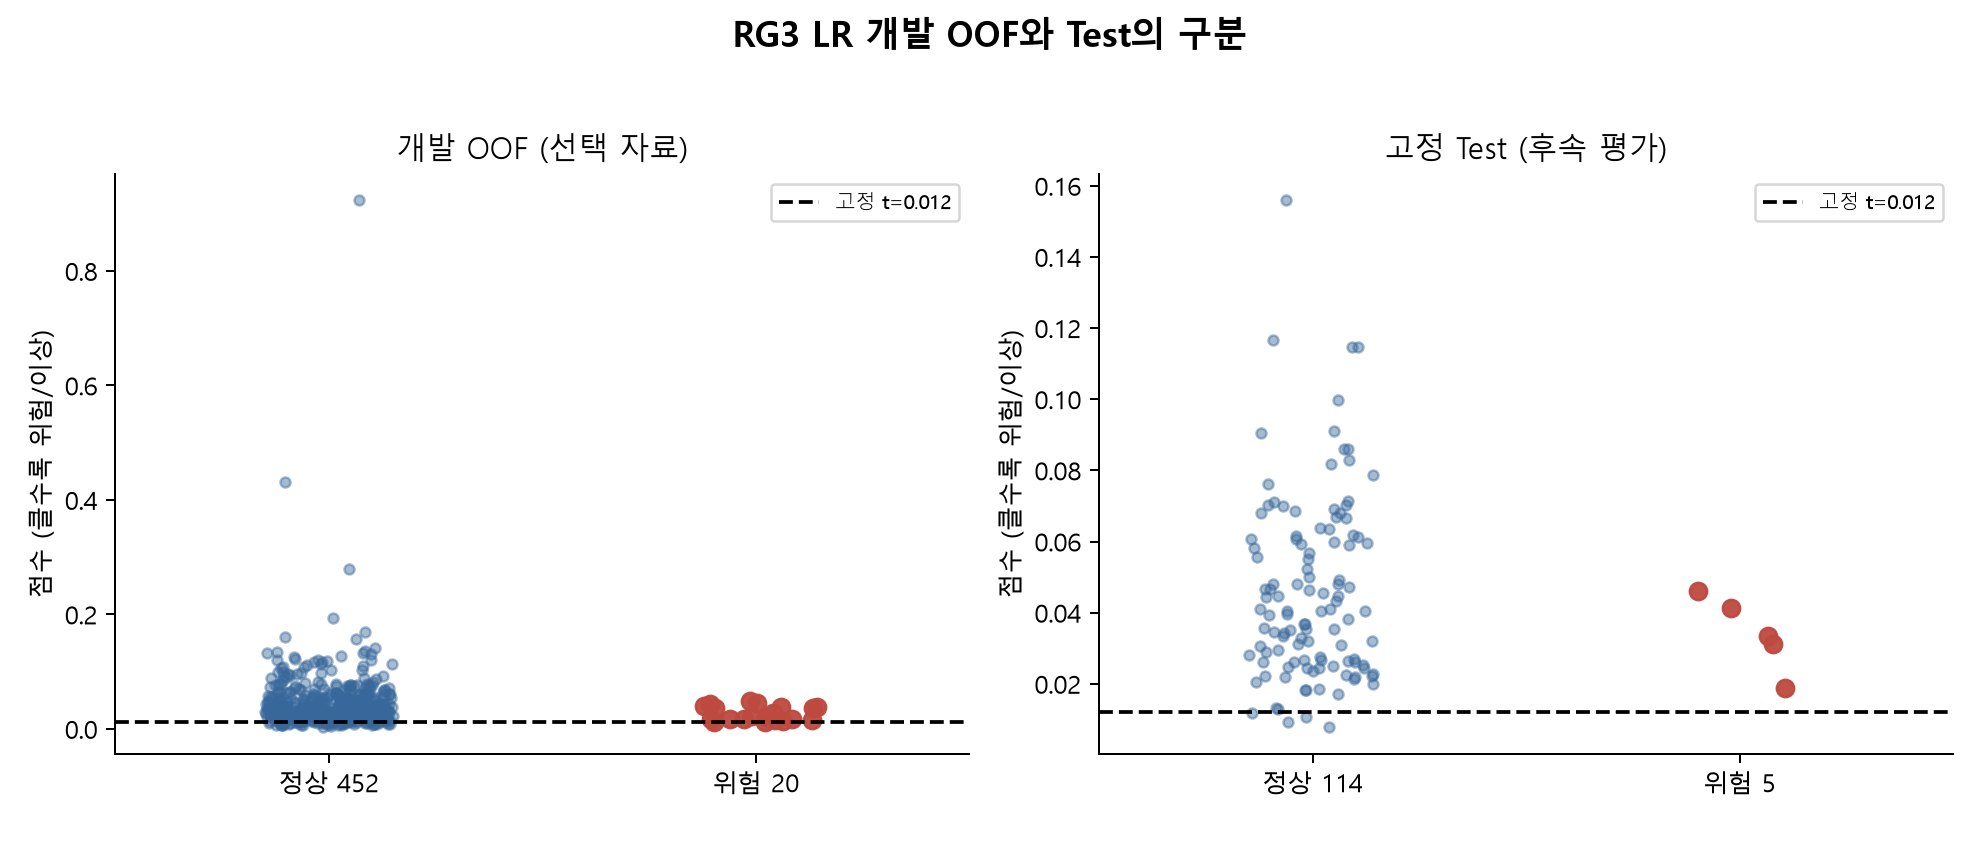

### RG3 선택 LR의 주요 계수

lr-20261003T041011Z-d707796f / 개발 적합 / 상위10 절대계수 / thermal 특징

계수 부호는 다른 입력을 포함한 모델 좌표에서의 관계이다. 물리적 원인이나 최적 공정값으로 해석하지 않았다.

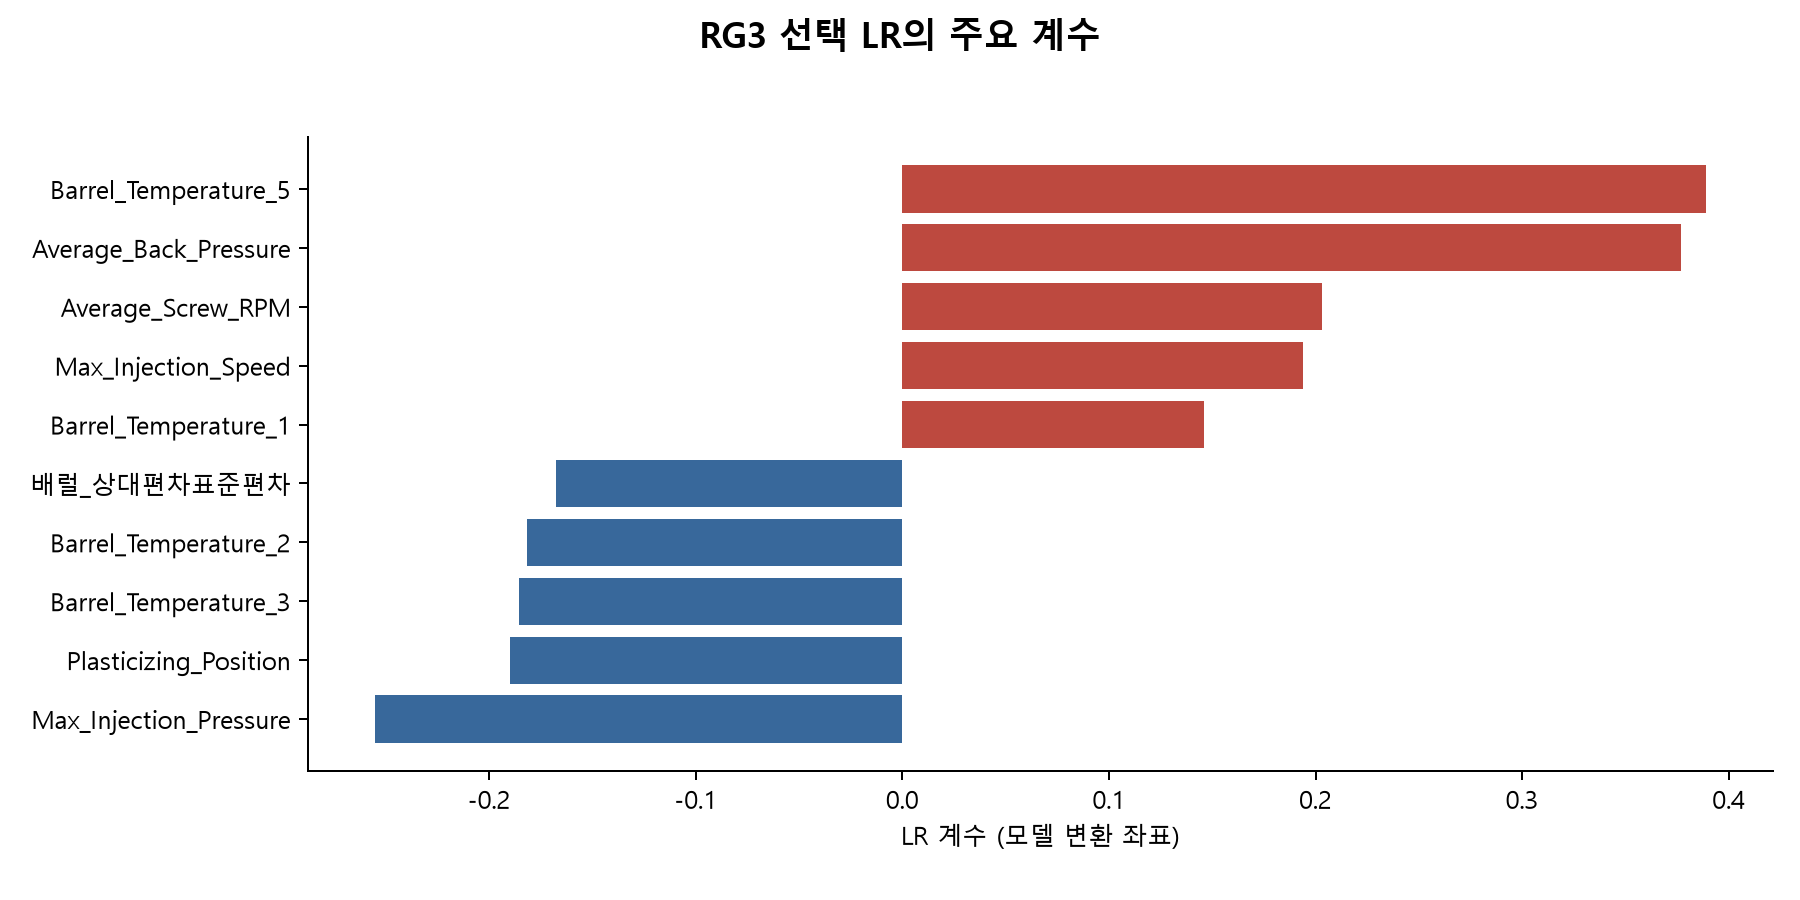

보고서 수록 그림: lr_scores, lr_confusion, cn7_lr_oof_test, cn7_lr_coefficients, rg3_lr_oof_test, rg3_lr_coefficients


In [7]:
# 보고서용 시각화: 기존 학습 셀을 실행하지 않고 저장 결과를 표시한다.
from pathlib import Path
import sys
_report_root = next(p for p in [Path.cwd(), *Path.cwd().parents]
                    if (p / "reporting/visualizations.py").is_file())
if str(_report_root) not in sys.path:
    sys.path.insert(0, str(_report_root))
from reporting.visualizations import show_notebook
_report_figure_ids = show_notebook('03.modeling/models/05_logistic_regression.ipynb')
print("보고서 수록 그림:", ", ".join(_report_figure_ids))
